# How Has Netflix's Content Strategy Changed Over Time?

## Introduction

This project analyzes Netflix's movies and TV shows to understand how its
content strategy has changed over time.

The analysis will look at the types of content available, release years,
genres, countries, ratings, and when content was added to Netflix.

The aim is to identify patterns in Netflix's catalog and explore what
these patterns might tell us about Netflix's business and content strategy.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("netflix_titles.csv")

In [18]:
import os
os.getcwd()

'C:\\Users\\Admin\\Downloads\\ACJ coding'

Look at your data

In [19]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Find out how big your dataset is

In [20]:
df.shape

(8807, 12)

See all your columns

In [21]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

Check for missing data

In [22]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Check Movies vs TV Shows

In [23]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [24]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Make the graph

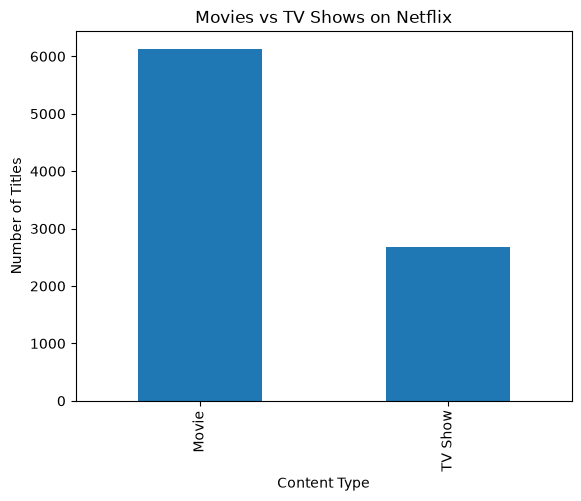

In [25]:
df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

Calculate percentages

In [26]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

### Finding: Movies vs TV Shows

The Netflix dataset contains more movies than TV show.

Movies account for approximately 69% of the catalog, while TV Shows
account for approximately 30%.

This suggests that Netflix's catalog has a stronger focus on movies.
However, the balance between movies and TV shows may have changed over
time, which we will investigate in the next part of the analysis.

change over time

In [28]:
df["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

graph

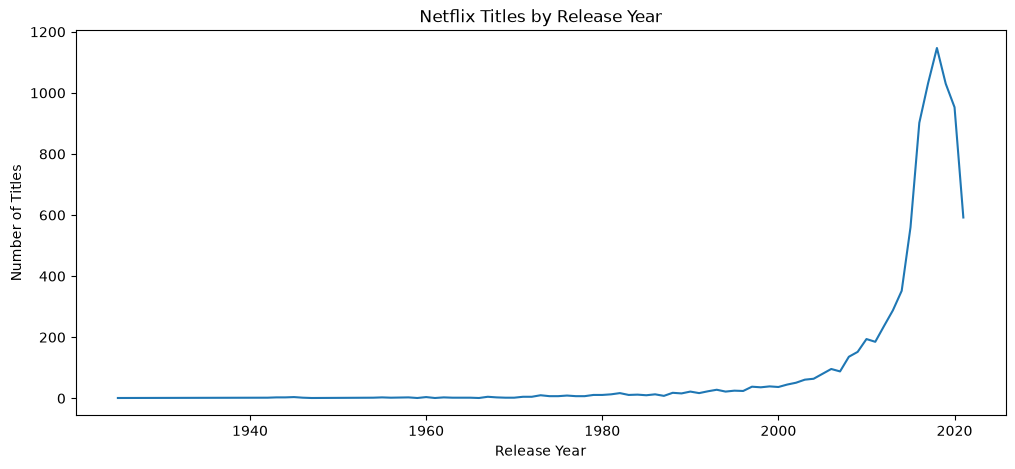

In [29]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [30]:
df["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [31]:
df["release_year"].min(), df["release_year"].max()

(np.int64(1925), np.int64(2021))

Finding: Netflix's Content Is Relatively Recent

The dataset contains Netflix titles released between 1925 and 2021. However, most of the content is from more recent years. The median release year is 2017, meaning that half of the titles were released in 2017 or later.

This suggests that Netflix's catalog is strongly focused on relatively recent content, although older movies and TV shows are also included.

when Netflix added the content

In [32]:
df["date_added"].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: str

In [35]:
df["date_added"] = df["date_added"].astype(str).str.strip()

In [36]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [37]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [38]:
df["date_added"].dt.year.value_counts().sort_index()

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

In [39]:
year_added = df["date_added"].dt.year.value_counts().sort_index(ascending=True)

print(year_added)

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


In [ ]:
graph 

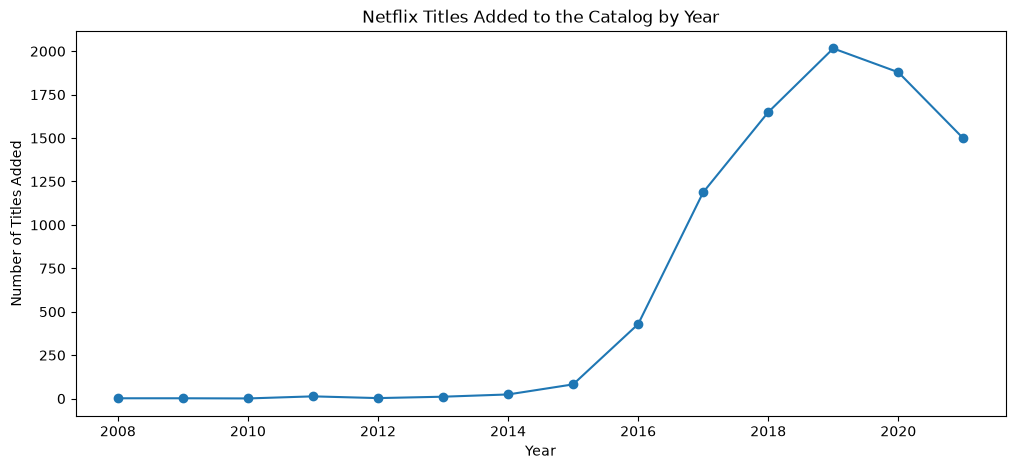

In [40]:
year_added = df["date_added"].dt.year.value_counts().sort_index(ascending=True)

plt.figure(figsize=(12, 5))
plt.plot(year_added.index, year_added.values, marker="o")

plt.title("Netflix Titles Added to the Catalog by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

### Finding: Rapid Growth in Netflix's Content Catalog

The number of titles added to Netflix increased dramatically from the mid-2010s. Only 82 titles were added in 2015, compared with 1,188 in 2017 and 2,016 in 2019, which was the highest point in the dataset.

After 2019, the number of titles added decreased to 1,879 in 2020 and 1,498 in 2021. Overall, the data shows a period of rapid catalog expansion, particularly between 2016 and 2019, followed by a decline in the number of titles added.

This suggests that Netflix significantly increased the scale of its content additions during the late 2010s.


MOVIES /TV SHOW OVERTIME

In [41]:
pd.crosstab(df["date_added"].dt.year, df["type"])

type,Movie,TV Show
date_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,5
2014.0,19,5
2015.0,56,26
2016.0,253,176


GRAPH 

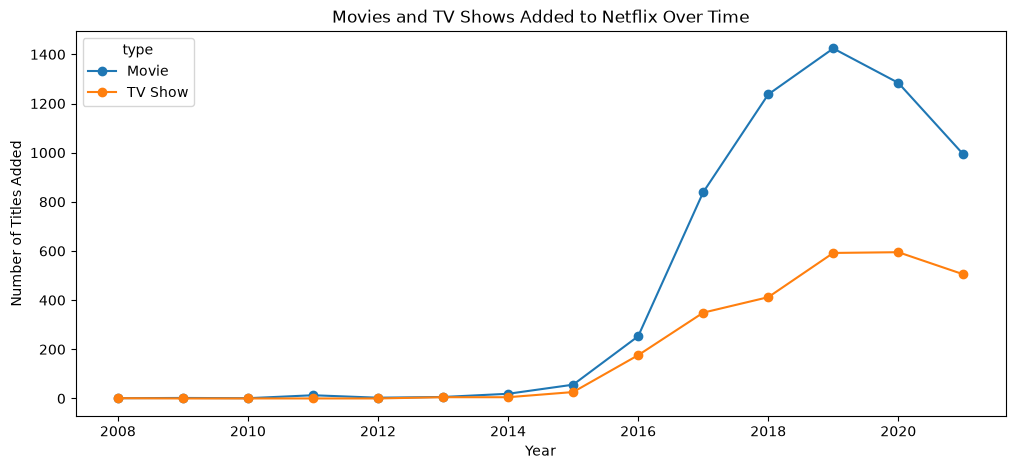

In [42]:
content_by_year = pd.crosstab(df["date_added"].dt.year, df["type"])

content_by_year.plot(kind="line", marker="o", figsize=(12, 5))

plt.title("Movies and TV Shows Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

finding is:

Movie additions increased sharply from 56 in 2015 → 1,424 in 2019.
TV Show additions also increased from 26 in 2015 → 592 in 2019.
Movies remained the larger category every year from 2013 onward.
TV Shows continued to make up a significant part of Netflix's additions, especially in 2019–2021.

### Finding: Netflix Expanded Both Movies and TV Shows

The data shows that Netflix significantly increased the number of both movies and TV shows added to its catalog over time. Movie additions increased from 56 in 2015 to a peak of 1,424 in 2019. TV Show additions also increased, from 26 in 2015 to 592 in 2019.

Movies remained the larger category throughout the period, but TV Shows became an increasingly important part of Netflix's content additions. After 2019, additions of both movies and TV shows declined, although Netflix continued adding more movies than TV shows.

This suggests that Netflix's content expansion involved both movies and TV shows, while movies remained the dominant part of its catalog.


In [ ]:
GENRE

In [43]:
genres = df["listed_in"].str.split(", ").explode()

genres.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

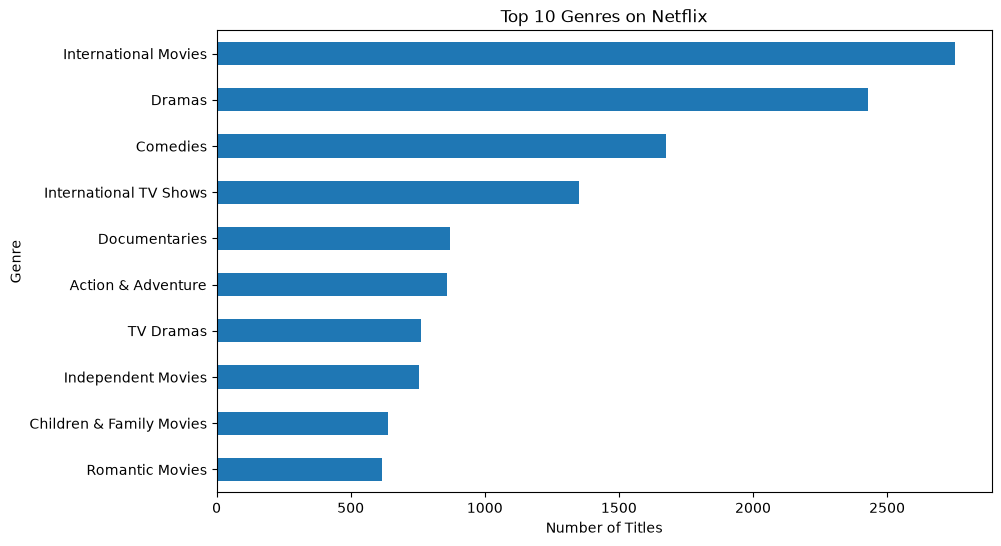

In [44]:
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 6))
top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

### Finding: International and Drama Content Dominate

The genre analysis shows that International Movies are the most common category in the dataset, with 2,752 titles, followed by Dramas with 2,427 titles and Comedies with 1,674 titles.

The large number of international categories suggests that Netflix has a strong focus on content from different countries and regions. Drama and comedy are also major parts of the catalog, showing a mix of international and broadly popular entertainment.

This suggests that Netflix's content strategy is not limited to one market and includes a strong emphasis on international content.


In [46]:
countries = df["country"].str.split(", ").explode()

countries.value_counts().head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [47]:
countries = df["country"].str.split(", ").explode()

countries.value_counts().head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

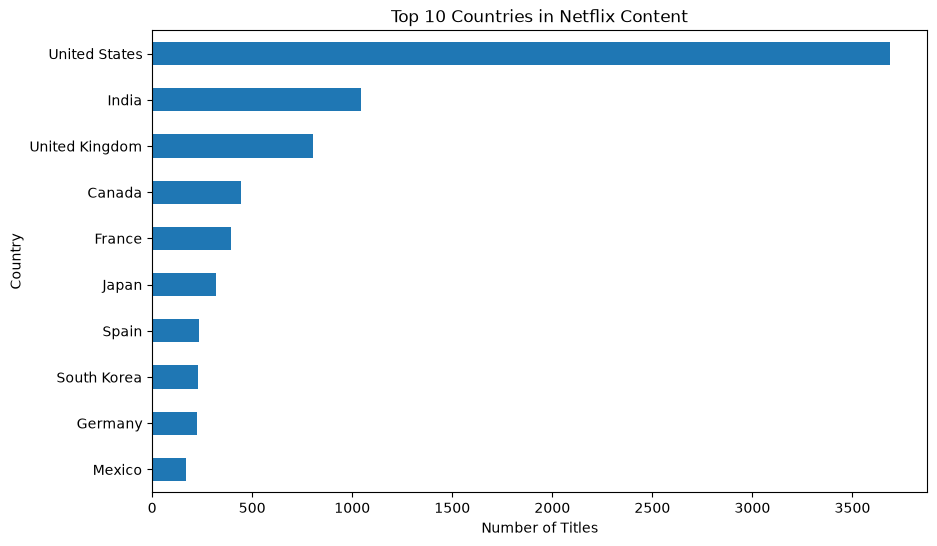

In [48]:
top_countries = countries.value_counts().head(10)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries in Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Finding: Netflix Has a Strong International Catalog

The United States is the largest country represented in the dataset, with 3,689 titles. India is second with 1,046 titles, followed by the United Kingdom with 804 titles and Canada with 445 titles.

The presence of countries such as India, Japan, Spain, South Korea, Germany, and Mexico among the top 10 shows that Netflix's catalog includes content from a wide range of international markets.

This supports the idea that Netflix has built a diverse and international content catalog rather than focusing only on content from the United States.


## Story Pitch: How Has Netflix's Content Strategy Changed Over Time?

Netflix's content strategy appears to have changed significantly over time, particularly during the late 2010s. The dataset shows that Netflix rapidly expanded its catalog, with the number of titles added increasing from just 82 in 2015 to a peak of 2,016 in 2019. Although movies remained the dominant type of content, TV shows also became an important part of Netflix's expansion.

The catalog is also relatively recent, with a median release year of 2017. In addition, the large number of international titles and the presence of countries such as India, Japan, South Korea, Spain, Germany, and Mexico suggest that Netflix developed a broad international catalog.

My story would explore how Netflix moved from primarily expanding its movie catalog toward a much larger, more recent, and internationally diverse content library. The main question is whether Netflix's rapid expansion in the late 2010s reflects a strategy to offer more content and reach audiences across different countries and markets.
